# Óptimo y consistencia de los parámetros

Vista del barrido del notebook `01`: **no vuelve a correr el modelo** salvo para
la especie que se grafica en detalle (celda 4, una sola combinación).

  * ROC y distribución de scores de la especie elegida;
  * efecto de cada parámetro sobre la AUC01 (**α**, β, λ, γ);
  * **β = 0 vs β > 0** — G′r vs G′rk. Como la grilla ya tiene β = 0, esta
    comparación es una *vista* del barrido y no un análisis aparte (README §1.5);
  * plateau del óptimo: cuánto se pierde al no elegir el argmax exacto;
  * consistencia entre especies y entre grupos taxonómicos.

Salidas: `02_optimos_por_especie.csv`, `02_consistencia.csv`, `02_plateau.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "genome_prioritization"))
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_genome as fg              # el .py de esta carpeta
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = tdr.out("genome_prioritization")
FIGURAS = SALIDAS / "figuras"
NB      = "02"                             # numero de este notebook: prefija todo lo que genere
n_core  = 20

plt = tdr.estilo()
SALIDAS

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out')

## Datos

In [2]:
BARRIDO = tdr.out("genome_prioritization")             # salidas del notebook 01
barrido = fg.cargar_barrido(BARRIDO, "01")
datos   = tdr.cargar_db(anotaciones=True, cluster_consistent=False)
barrido.shape, tdr.leer_meta(BARRIDO, "01")["fecha"]

· 00_specie_target


· 03_bioactivities_target_compound


· 04a_interpro / 04b_orthomcl


((1920, 10), '2026-09-10 10:33')

## Acondicionamiento

In [3]:
spout = tdr.SP_FOCO                                      # el protozoo parásito que se mira en detalle
optimos = fg.optimos_por_especie(barrido)
alpha_val, beta_val, lam_val, gamma_val = optimos.loc[
    optimos["especie"] == spout, ["alpha", "beta", "lambda_", "gamma"]].values[0]
lam_val = None if pd.isna(lam_val) else lam_val         # NaN = modo híbrido

print(f"{spout}: alpha={alpha_val} beta={beta_val} lambda={lam_val} gamma={gamma_val}")
optimos[["especie", "AUC01", "AUC", "alpha", "beta", "lambda_", "gamma"]]

26: alpha=1.2 beta=1.0 lambda=1.0 gamma=0.8


,especie,AUC01,AUC,alpha,beta,lambda_,gamma
0,0,0.580825,0.865912,1.2,1.0,NaN,0.8
1,1,0.587958,0.820488,1.2,1.0,1.0,0.8
2,3,0.594217,0.769365,0.0,0.5,1.0,0.8
3,4,0.849387,0.882784,0.0,1.0,1.0,0.8
4,5,0.591185,0.878259,0.3,0.5,0.5,0.8
5,9,0.663685,0.780799,0.3,1.5,1.0,0.8
6,10,0.581274,0.743434,0.9,0.0,0.0,0.8
7,15,0.788785,0.844365,0.3,1.5,NaN,0.8
8,17,0.614049,0.811996,0.0,1.0,1.0,0.8
9,18,0.610904,0.817568,0.3,1.0,NaN,0.8


## Corrida

In [4]:
# celda de corrida: una sola combinación (la óptima de spout) para poder graficar la ROC
ctx = fg.preparar_especie(datos, spout)
cat_rs = tdr.relevance_scores(alpha=alpha_val, pv=ctx["cat_rs"])
rnk = tdr.propagar(datos.sta, ctx["seed"], cat_rs, beta=beta_val, lambda_=lam_val, gamma=gamma_val)
rnk["target_id"] = rnk["target_id"].astype(str)
rnk["druggable"] = rnk["target_id"].isin(ctx["tp"]).astype(int)
sp_rnk = tdr.ranking_especie(rnk, ctx["sp_targets"], ctx["tp"])
print(f"AUC01 de {spout} en su óptimo: {tdr.auc01_mcclish(sp_rnk['druggable'], sp_rnk['score']):.4f}")

frecuencias, spearman = fg.consistencia(barrido, k=10)
pl = fg.plateau(barrido)

optimos.to_csv(SALIDAS / f"{NB}_optimos_por_especie.csv", index=False)
frecuencias.to_csv(SALIDAS / f"{NB}_consistencia.csv", index=False)
spearman.to_csv(SALIDAS / f"{NB}_spearman_especies.csv")
pl.to_csv(SALIDAS / f"{NB}_plateau.csv", index=False)
fg.tabla_ranking(rnk, ctx).to_csv(SALIDAS / f"{NB}_ranking_{spout}.csv", index=False)  # <- la ROC
fg.escribir_meta(SALIDAS, NB, notebook="02_optimo_y_consistencia.ipynb",
                 params=fg.PARAMS, especie_detalle=spout, barrido_nb="01")

AUC01 de 26 en su óptimo: 0.7365


  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/02_meta.json


{'notebook': '02_optimo_y_consistencia.ipynb',
 'nb': '02',
 'fecha': '2026-09-10 10:34',
 'params': {'alpha': [0, 0.3, 0.6, 0.9, 1.2],
  'beta': [0, 0.5, 1.0, 1.5],
  'lambda_': [0.0, 0.5, 1.0, None],
  'gamma': [0.8, 1.0, 1.2]},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-09-08',
  '01_clusters_fingerprint.csv': '2026-09-08',
  '01_edges_clusters_fingerprint.part00.csv.gz': '2026-09-08',
  '01_edges_clusters_fingerprint.part01.csv.gz': '2026-09-08',
  '02_clusters_subestructure.csv': '2026-09-08',
  '02_edges_clusters_subestructure.csv': '2026-09-08',
  '03_bioactivities_organism_compound.csv': '2026-09-08',
  '03_bioactivities_target_compound.csv': '2026-09-08',
  '04a_interpro.csv': '2026-09-08',
  '04b_orthomcl.csv': '2026-09-08'},
 'python': '3.12.11',
 'pandas': '3.0.5',
 'especie_detalle': 26,
 'barrido_nb': '01'}

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_genome.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py genome_prioritization

In [5]:
optimos     = pd.read_csv(SALIDAS / f"{NB}_optimos_por_especie.csv")
frecuencias = pd.read_csv(SALIDAS / f"{NB}_consistencia.csv")
spearman    = pd.read_csv(SALIDAS / f"{NB}_spearman_especies.csv", index_col=0)
pl          = pd.read_csv(SALIDAS / f"{NB}_plateau.csv")
pl

,especie,n_combos,auc01_max,auc01_min,caida_top5,caida_top10,caida_top20,n_dentro_0.001,n_dentro_0.005,n_dentro_0.01
0,4,120,0.849387,0.550453,0.004282,0.008241,0.010855,2,5,16
1,15,120,0.788785,0.529608,0.002435,0.004772,0.011445,3,10,13
2,23,120,0.742940,0.541274,0.002255,0.003021,0.015519,2,12,17
3,26,120,0.736463,0.571853,0.006499,0.013980,0.019009,2,4,8
4,21,120,0.683361,0.516395,0.002113,0.005228,0.008285,1,8,35
5,9,120,0.663685,0.551888,0.008013,0.011164,0.015372,1,3,7
6,22,120,0.652077,0.523768,0.011166,0.015944,0.021405,2,2,4
7,25,120,0.645299,0.580104,0.001428,0.002867,0.013552,2,13,18
8,28,120,0.644337,0.508381,0.001791,0.002447,0.004579,1,21,29
9,17,120,0.614049,0.556121,0.008228,0.010753,0.015639,1,3,7


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/02_f01_roc_26.pdf


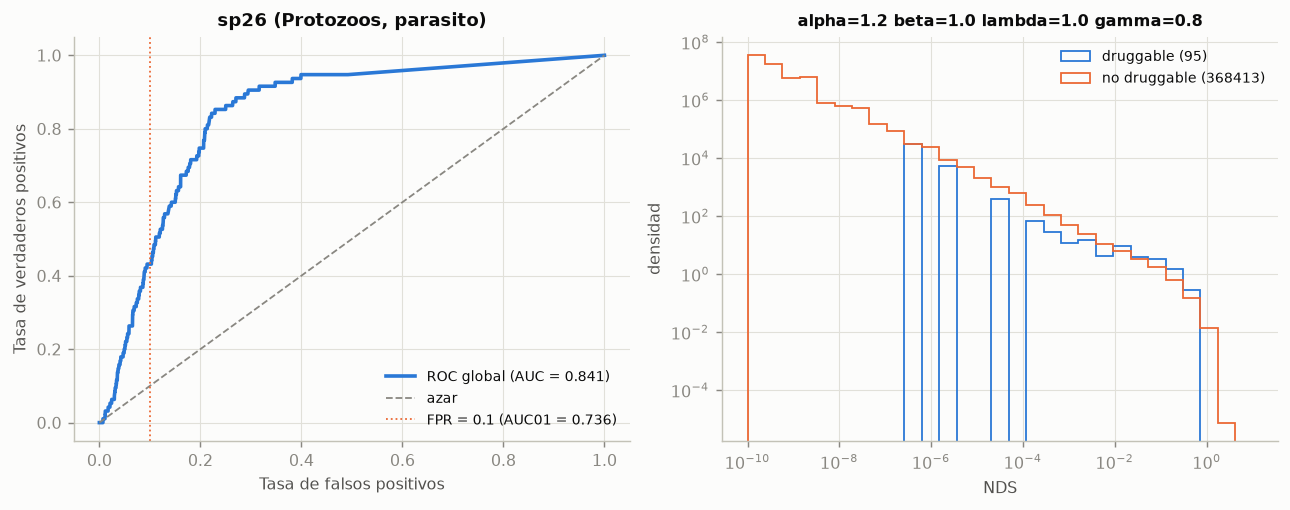

In [6]:
F.dibujar(f"{NB}_f01_roc_{spout}");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/02_f02_grilla_beta.pdf


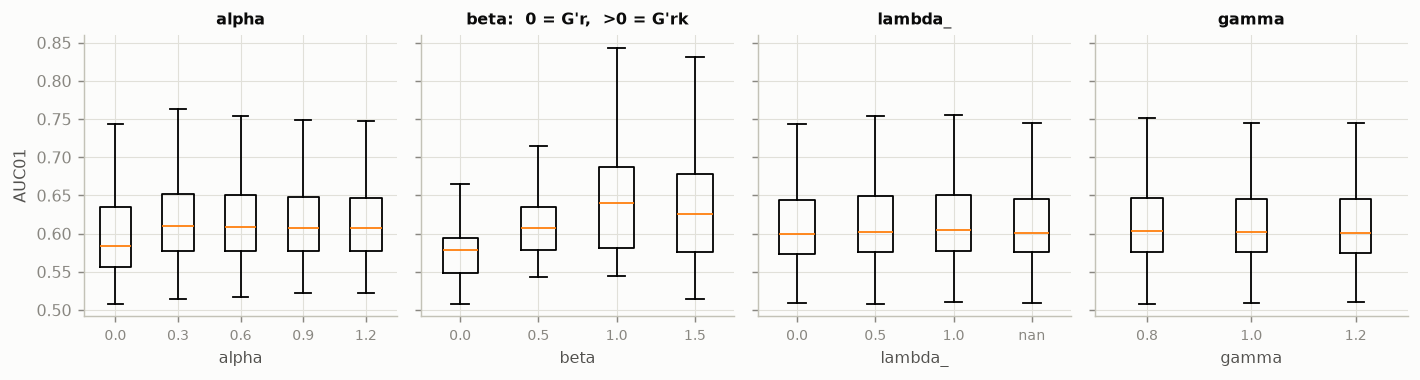

In [7]:
# Efecto de cada parámetro; el panel de beta es G'r (beta=0) vs G'rk (beta>0)
F.dibujar("02_f02_grilla_beta");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/02_f03_plateau.pdf


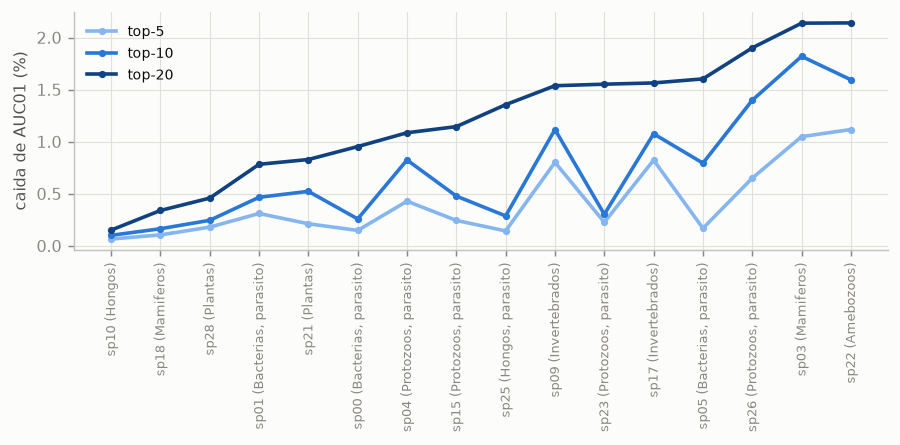

In [8]:
F.dibujar("02_f03_plateau");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/02_f04_consistencia_especies.pdf


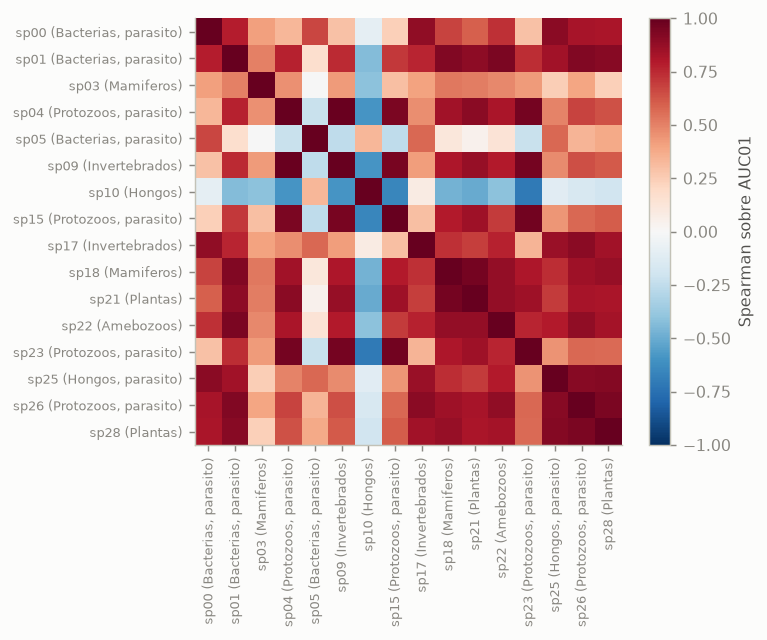

In [9]:
F.dibujar("02_f04_consistencia_especies");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/genome_prioritization_out/figuras/02_f05_enriquecimiento_topk.pdf


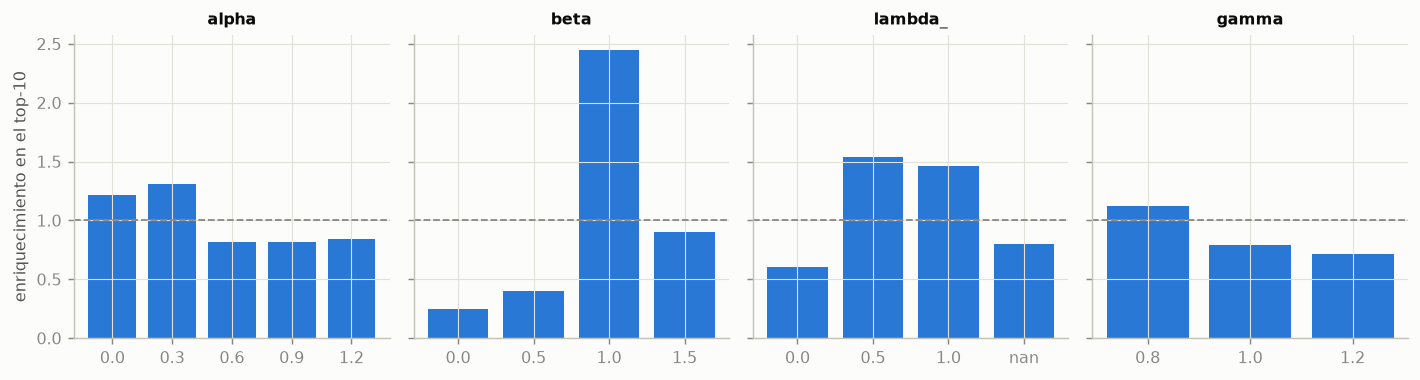

In [10]:
# Enriquecimiento de cada valor de parámetro en el top-10: el factor dominante
F.dibujar("02_f05_enriquecimiento_topk");